# 16 · Residuos Parciales y No Linealidad

Después de ajustar un modelo lineal, los **residuos parciales** (partial residuals) nos permiten evaluar si la relación entre cada predictor y la respuesta es realmente lineal.

$$\text{Residuo parcial}_j = e + \hat{\beta}_j \cdot x_j$$

donde $e$ es el residuo ordinario y $\hat{\beta}_j x_j$ es el término de regresión del predictor $j$.

> 👈 Si el modelo lineal captura bien la relación, el smooth y la línea recta deberían coincidir. Si hay **curvatura**, el predictor necesita un término no lineal.

In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

df = pd.read_csv("../data/apartments.csv")
print(df.head())
print(f"\nShape: {df.shape}")

    area  rooms  distance_km   age   price
0  273.9      4         19.7   6.4  531290
1  196.7      5          8.6  40.6  537317
2  294.7      3         16.5  41.0  489549
3  194.2      5         16.2  31.3  500970
4  201.9      5          3.9  41.0  541741

Shape: (200, 5)


## 1 · Modelo Lineal Base

Ajustamos un modelo lineal con 4 predictores. Sabemos que `area` tiene una relación **logarítmica** con `price`, pero el modelo asume que es lineal.

In [20]:
predictors = ["area", "rooms", "distance_km", "age"]

X = df[predictors]
y = df["price"]

ols = sm.OLS(y, sm.add_constant(X)).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     425.3
Date:                Sun, 29 Mar 2026   Prob (F-statistic):           4.24e-95
Time:                        18:02:21   Log-Likelihood:                -2256.4
No. Observations:                 200   AIC:                             4523.
Df Residuals:                     195   BIC:                             4539.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3.493e+05   5490.697     63.622      

## 2 · ¿Qué es un Residuo Parcial?

El residuo parcial **aísla** la contribución de un predictor a la respuesta, controlando por los demás:

$$\text{PR}_j = \underbrace{e}_{\text{lo que el modelo no explica}} + \underbrace{\hat{\beta}_j \cdot x_j}_{\text{contribución lineal de } x_j}$$

Es como preguntar: *"Si solo tuviéramos este predictor, ¿cómo se vería su relación con $y$?"*

- Si la relación es **lineal** → los puntos siguen la línea recta
- Si hay **curvatura** → los puntos se desvían sistemáticamente de la línea

In [21]:
# Cálculo manual para 'area' — ejemplo con la primera fila
EJEMPLO = 0  # fila 0: apartamento de 273.9 m², precio $531,290

e = ols.resid
beta_area = ols.params["area"]

partial_resid_area = e + beta_area * df["area"]

print(f"β_area = {beta_area:.2f}")
print(f"Residuo fila {EJEMPLO}:          {e.iloc[EJEMPLO]:.0f}")
print(f"Término lineal fila {EJEMPLO}:   {beta_area * df['area'].iloc[EJEMPLO]:.0f}")
print(f"Residuo parcial fila {EJEMPLO}:  {partial_resid_area.iloc[EJEMPLO]:.0f}")

β_area = 586.15
Residuo fila 0:          -770
Término lineal fila 0:   160546
Residuo parcial fila 0:  159775


## 3 · Residuos Parciales con statsmodels (CCPR)

`plot_ccpr` (Component-Component Plus Residual) genera el gráfico de residuos parciales automáticamente:

- **Línea recta** (azul): el término lineal $\hat{\beta}_j x_j$
- **Puntos**: los residuos parciales $e + \hat{\beta}_j x_j$

Si los puntos siguen la línea → la relación lineal es adecuada.

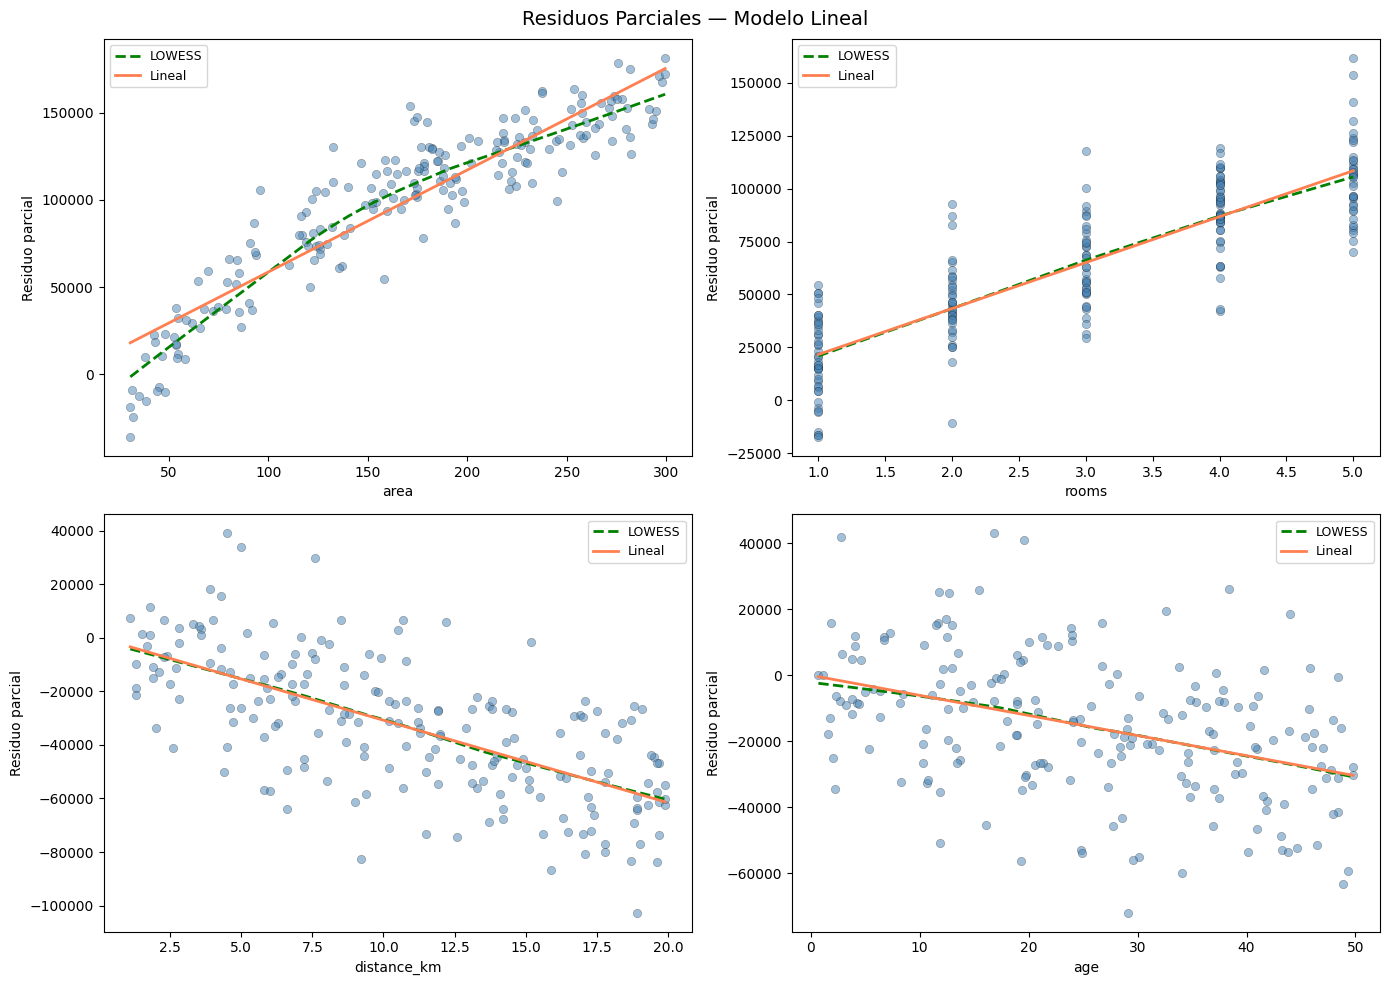

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, pred in zip(axes.flat, predictors):
    beta = ols.params[pred]
    pr = e + beta * df[pred]

    sns.scatterplot(
        x=df[pred],
        y=pr,
        ax=ax,
        color="steelblue",
        alpha=0.5,
        edgecolor="k",
        linewidth=0.3,
    )

    # lowess=True → curva LOWESS (smooth local, sin asumir forma)
    # scatter=False → no repite los puntos, solo dibuja la curva
    sns.regplot(
        x=df[pred],
        y=pr,
        ax=ax,
        scatter=False,
        lowess=True,
        line_kws={"color": "green", "linestyle": "--", "linewidth": 2},
        label="LOWESS",
    )

    x_range = np.sort(df[pred])
    ax.plot(x_range, beta * x_range, color="coral", linewidth=2, label="Lineal")
    ax.set_xlabel(pred)
    ax.set_ylabel("Residuo parcial")
    ax.legend(fontsize=9)

fig.suptitle("Residuos Parciales — Modelo Lineal", fontsize=14)
plt.tight_layout()
plt.show()

### Lectura del gráfico

- **rooms, distance_km, age**: los puntos siguen la línea recta → relación lineal OK
- **area**: los puntos forman una **curva** — el modelo lineal subestima para áreas pequeñas y sobreestima para áreas medianas

> 🚨 La curvatura en `area` indica que necesitamos un **término no lineal** para ese predictor.

## 4 · Zoom: `area` — Línea vs Smooth

Veamos `area` en detalle con un LOWESS smooth para comparar la tendencia real vs lo que el modelo lineal asume.

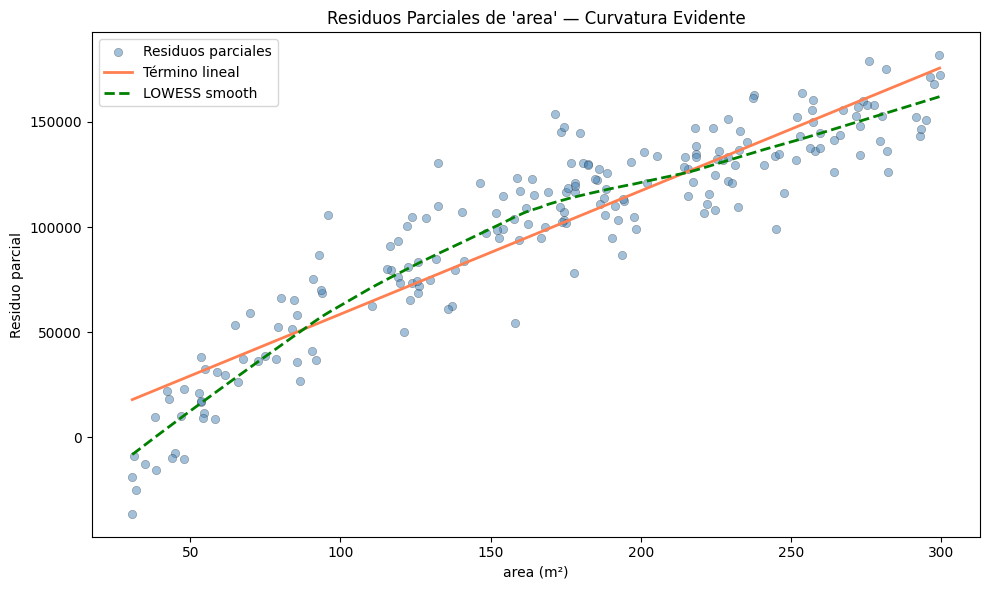

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df["area"],
    partial_resid_area,
    color="steelblue",
    alpha=0.5,
    edgecolors="k",
    linewidth=0.3,
    label="Residuos parciales",
)

# Línea del modelo lineal
x_sorted = np.sort(df["area"])
ax.plot(
    x_sorted, beta_area * x_sorted, color="coral", linewidth=2, label="Término lineal"
)

# LOWESS smooth
lowess = sm.nonparametric.lowess(partial_resid_area, df["area"], frac=0.4)
ax.plot(
    lowess[:, 0],
    lowess[:, 1],
    color="green",
    linewidth=2,
    linestyle="--",
    label="LOWESS smooth",
)

ax.set_xlabel("area (m²)")
ax.set_ylabel("Residuo parcial")
ax.set_title("Residuos Parciales de 'area' — Curvatura Evidente")
ax.legend()
plt.tight_layout()
plt.show()

## 5 · Corrigiendo la No Linealidad

El gráfico sugiere una relación logarítmica. Reemplazamos `area` por `log(area)` y comparamos.

In [28]:
df["log_area"] = np.log(df["area"])
predictors_v2 = ["log_area", "rooms", "distance_km", "age"]

X_v2 = df[predictors_v2]
ols_v2 = sm.OLS(y, sm.add_constant(X_v2)).fit()

print(f"{'Modelo':<20} {'R²':>8} {'AIC':>10}")
print(f"{'Lineal (area)':<20} {ols.rsquared:>8.4f} {ols.aic:>10.1f}")
print(f"{'Log (log_area)':<20} {ols_v2.rsquared:>8.4f} {ols_v2.aic:>10.1f}")
print(f"\n✅ R² mejoró de {ols.rsquared:.4f} a {ols_v2.rsquared:.4f}")
print(f"✅ AIC bajó de {ols.aic:.0f} a {ols_v2.aic:.0f} (menor = mejor)")

Modelo                     R²        AIC
Lineal (area)          0.8972     4522.7
Log (log_area)         0.9326     4438.3

✅ R² mejoró de 0.8972 a 0.9326
✅ AIC bajó de 4523 a 4438 (menor = mejor)


## 6 · Verificación: CCPR del Modelo Corregido

Ahora los residuos parciales de `log_area` deberían seguir la línea recta.

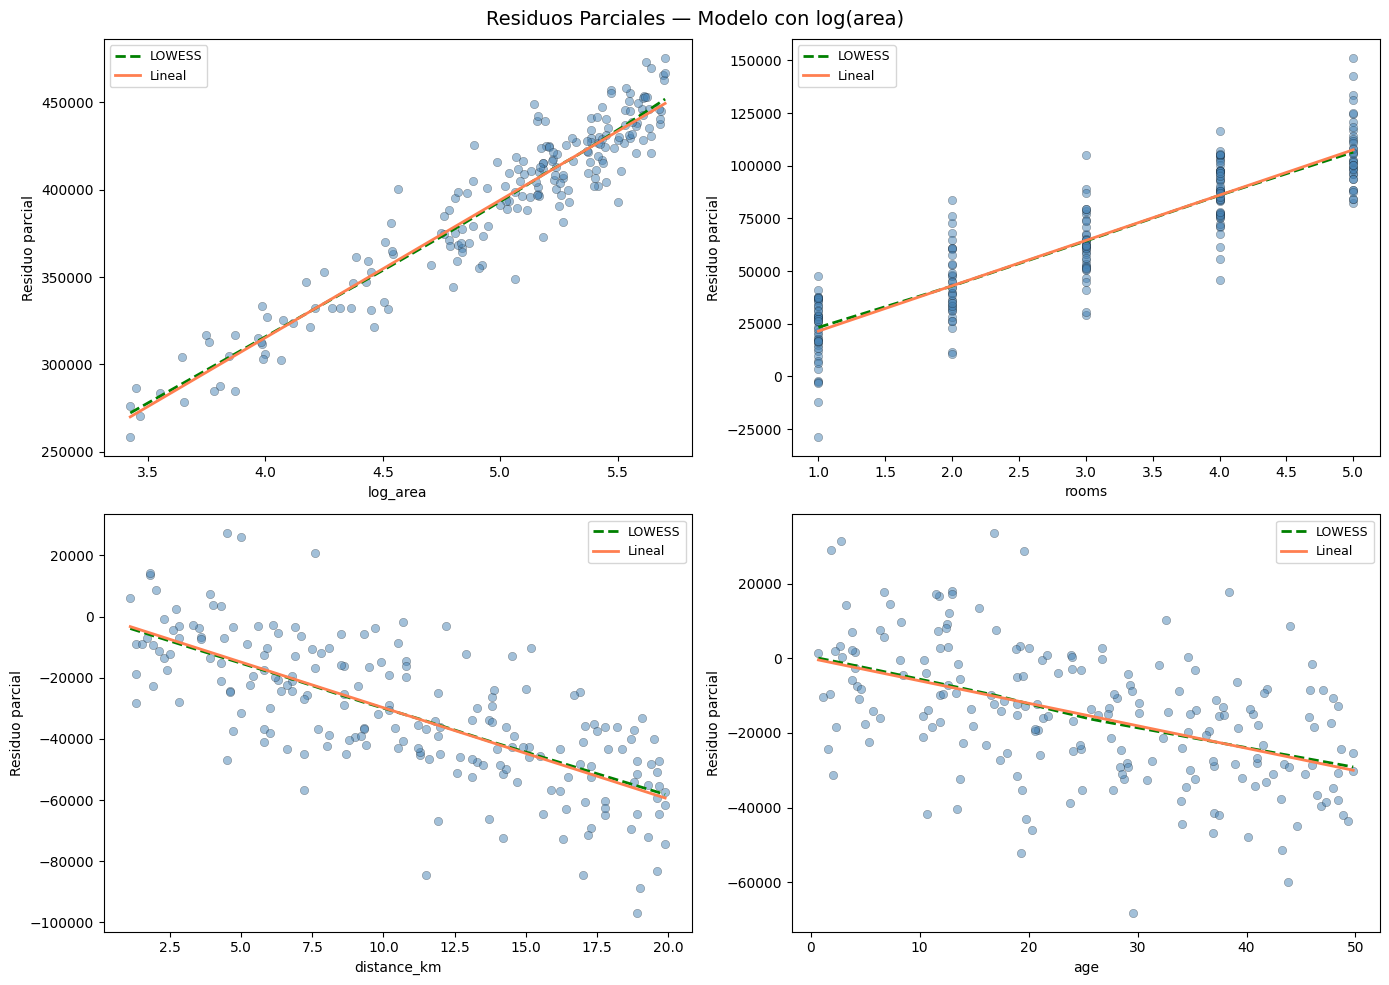

In [31]:
e_v2 = ols_v2.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, pred in zip(axes.flat, predictors_v2):
    beta = ols_v2.params[pred]
    pr = e_v2 + beta * df[pred]

    sns.scatterplot(
        x=df[pred],
        y=pr,
        ax=ax,
        color="steelblue",
        alpha=0.5,
        edgecolor="k",
        linewidth=0.3,
    )
    sns.regplot(
        x=df[pred],
        y=pr,
        ax=ax,
        scatter=False,
        lowess=True,
        line_kws={"color": "green", "linestyle": "--", "linewidth": 2},
        label="LOWESS",
    )

    x_range = np.sort(df[pred])
    ax.plot(x_range, beta * x_range, color="coral", linewidth=2, label="Lineal")
    ax.set_xlabel(pred)
    ax.set_ylabel("Residuo parcial")
    ax.legend(fontsize=9)

fig.suptitle("Residuos Parciales — Modelo con log(area)", fontsize=14)
plt.tight_layout()
plt.show()

## 7 · Comparación Visual: Antes vs Después

Veamos el residuo parcial de `area` en ambos modelos lado a lado.

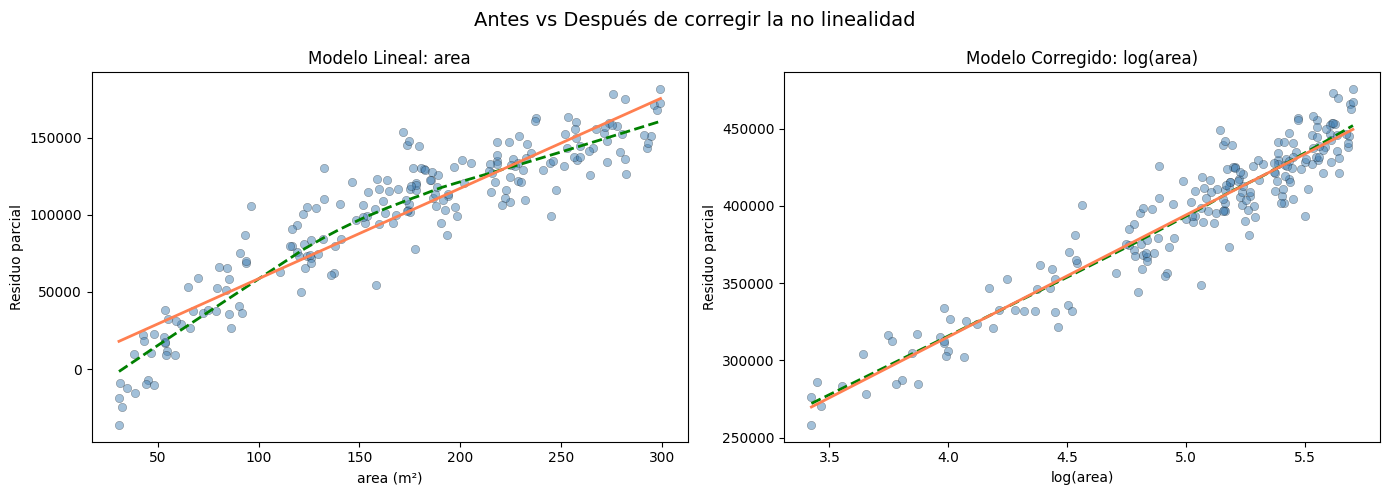

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modelo lineal: area
ax = axes[0]
pr_v1 = e + ols.params["area"] * df["area"]
sns.scatterplot(
    x=df["area"],
    y=pr_v1,
    ax=ax,
    color="steelblue",
    alpha=0.5,
    edgecolor="k",
    linewidth=0.3,
)
sns.regplot(
    x=df["area"],
    y=pr_v1,
    ax=ax,
    scatter=False,
    lowess=True,
    line_kws={"color": "green", "linestyle": "--", "linewidth": 2},
)
x_sorted = np.sort(df["area"])
ax.plot(x_sorted, ols.params["area"] * x_sorted, color="coral", linewidth=2)
ax.set_title("Modelo Lineal: area")
ax.set_xlabel("area (m²)")
ax.set_ylabel("Residuo parcial")

# Modelo con log: log_area
ax = axes[1]
pr_v2 = e_v2 + ols_v2.params["log_area"] * df["log_area"]
sns.scatterplot(
    x=df["log_area"],
    y=pr_v2,
    ax=ax,
    color="steelblue",
    alpha=0.5,
    edgecolor="k",
    linewidth=0.3,
)
sns.regplot(
    x=df["log_area"],
    y=pr_v2,
    ax=ax,
    scatter=False,
    lowess=True,
    line_kws={"color": "green", "linestyle": "--", "linewidth": 2},
)
x_sorted = np.sort(df["log_area"])
ax.plot(x_sorted, ols_v2.params["log_area"] * x_sorted, color="coral", linewidth=2)
ax.set_title("Modelo Corregido: log(area)")
ax.set_xlabel("log(area)")
ax.set_ylabel("Residuo parcial")

plt.suptitle("Antes vs Después de corregir la no linealidad", fontsize=14)
plt.tight_layout()
plt.show()

## 8 · Impacto en las Predicciones

La no linealidad no solo afecta el $R^2$ — cambia las **predicciones** de forma sistemática.

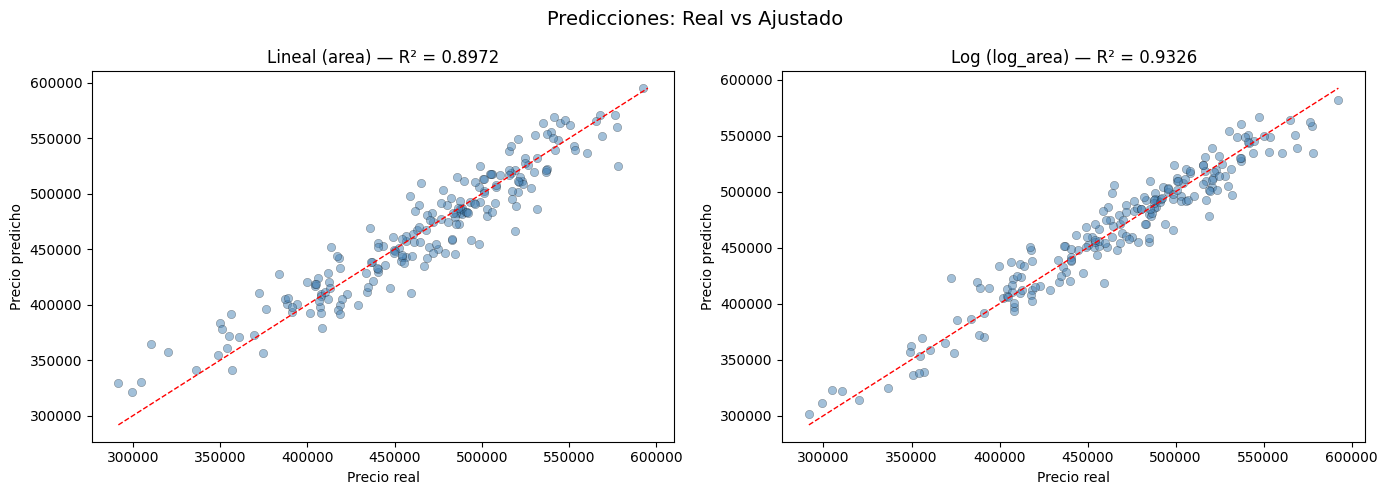

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, label in [
    (axes[0], ols, "Lineal (area)"),
    (axes[1], ols_v2, "Log (log_area)"),
]:
    y_hat = model.fittedvalues
    ax.scatter(y, y_hat, color="steelblue", alpha=0.5, edgecolors="k", linewidth=0.3)
    lims = [min(y.min(), y_hat.min()), max(y.max(), y_hat.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Precio real")
    ax.set_ylabel("Precio predicho")
    ax.set_title(f"{label} — R² = {model.rsquared:.4f}")

plt.suptitle("Predicciones: Real vs Ajustado", fontsize=14)
plt.tight_layout()
plt.show()

## 9 · Resumen

| Concepto | Descripción |
|----------|-------------|
| Residuo parcial | $e + \hat{\beta}_j x_j$ — aísla la relación predictor-respuesta |
| CCPR Plot | Gráfico de residuos parciales (Component-Component Plus Residual) |
| Curvatura | La línea recta no sigue el smooth → relación no lineal |
| LOWESS | Smooth local que revela la tendencia real sin asumir forma |

| Señal en el gráfico | Acción |
|---------------------|--------|
| Puntos siguen la línea | Relación lineal OK, no cambiar nada |
| Curvatura logarítmica | Transformar $x_j$ con $\log(x_j)$ |
| Curvatura cuadrática | Agregar $x_j^2$ como predictor |
| Curvatura compleja | Considerar splines o regresión no paramétrica |

> 👈 Los residuos parciales son la herramienta principal para decidir si un predictor necesita una transformación no lineal.